In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc,
    classification_report
)
from numpy import argmax
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=2)

In [16]:
model = LogisticRegression().fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


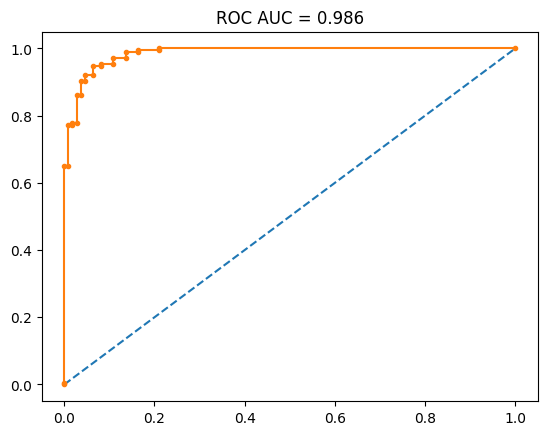

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot([0, 1], [0, 1], '--')
plt.plot(fpr, tpr, marker='.')
plt.title(f'ROC AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.show()

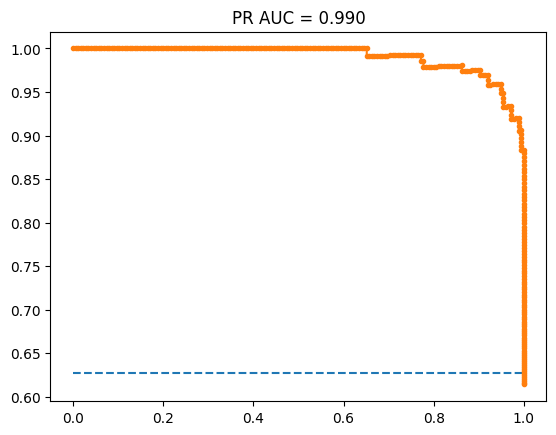

In [18]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
no_skill = y.mean()
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision, marker='.')
plt.title(f'PR AUC = {auc(recall, precision):.3f}')
plt.show()

In [19]:
y_pred = model.predict(X_test)
print('Default threshold (0.5):\n',
      classification_report(y_test, y_pred))

Default threshold (0.5):
               precision    recall  f1-score   support

           0       0.93      0.89      0.91       110
           1       0.93      0.96      0.95       175

    accuracy                           0.93       285
   macro avg       0.93      0.93      0.93       285
weighted avg       0.93      0.93      0.93       285



In [20]:
f1_scores = (2 * precision * recall) / (precision + recall)
ix = argmax(f1_scores)
best_thresh = _[ix]
print(f'\nBest threshold = {best_thresh:.3f}, F1 = {f1_scores[ix]:.3f}')


Best threshold = 0.697, F1 = 0.954


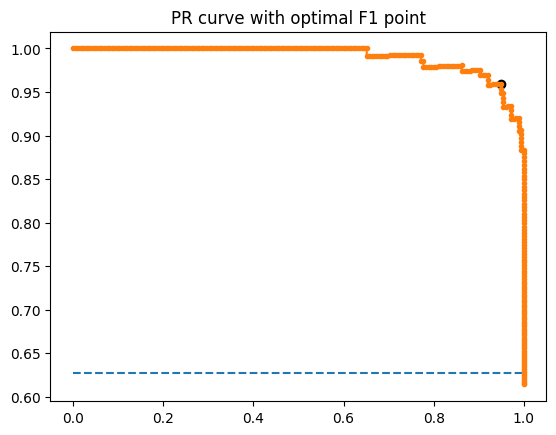

In [21]:
plt.figure()
plt.plot([0, 1], [no_skill, no_skill], '--')
plt.plot(recall, precision, marker='.')
plt.scatter(recall[ix], precision[ix], color='black')
plt.title('PR curve with optimal F1 point')
plt.show()

In [22]:
y_pred_opt = (y_proba > best_thresh).astype(int)
print('\nUsing optimal threshold:\n',
      classification_report(y_test, y_pred_opt))


Using optimal threshold:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92       110
           1       0.96      0.94      0.95       175

    accuracy                           0.94       285
   macro avg       0.94      0.94      0.94       285
weighted avg       0.94      0.94      0.94       285

